## 1. Introduction

This project aims to automate the detection and classification of brain tumors using **Magnetic Resonance Imaging (MRI)** scans. Early and accurate diagnosis of brain tumors is critical for effective treatment planning. 

In this study, we leverage Deep Learning techniques to classify MRI images into four distinct categories:
* **Glioma:** A type of tumor that occurs in the brain and spinal cord.
* **Meningioma:** A tumor that arises from the membranes surrounding the brain.
* **Pituitary:** Tumors that develop in the pituitary gland at the brain's base.
* **No Tumor:** Healthy brain scans used as a control group for evaluation.

---

##  Project Objective
The primary goal is to conduct a rigorous comparative study between two fundamental neural network architectures to understand their strengths and limitations:

### A. Feedforward Neural Network (FFNN)
* To evaluate how a basic dense architecture handles high-dimensional flattened image data.
* To establish a baseline performance for classification tasks.

### B. Convolutional Neural Network (CNN)
* To demonstrate the effectiveness of spatial feature extraction and pattern recognition.
* To compare its performance against the traditional FFNN in computer vision tasks.

In [60]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [61]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset

##  Data Loading & Directory Setup

In this step, we define the directory structure for our dataset. Organizing the paths is crucial for a scalable preprocessing pipeline. 

* **Base Path:** The main folder containing the dataset.
* **Train/Test Directories:** We explicitly define the paths for training and testing data to ensure the model learns from the correct subset and is evaluated on unseen data.
* **Class Labels:** We define the four target categories: `glioma`, `meningioma`, `notumor`, and `pituitary`. These labels correspond to the sub-folders in our dataset, which will be used to map images to their respective diagnoses.

> **Note:** This structure allows us to automate the image loading process and ensures consistency across the Training and Testing phases.

In [62]:
train_dir = 'training'
test_dir = 'testing'
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']


## 2.1 Exploratory Data Analysis (EDA)

 - Dataset Summary

After setting up the directories, we performed a data audit to understand the distribution of samples across different classes. This step is crucial for identifying any potential **Class Imbalance** issues.

### Key Observations:
* **Total Training Samples:** 5,600 images (1,400 per class).
* **Total Testing Samples:** 1,600 images (400 per class).

In [63]:
def get_data_summary(directory, classes):
    summary = []
    for label in classes:
        path = os.path.join(directory, label)
        # Count the number of files in the folder
        count = len(os.listdir(path))
        summary.append({'Class': label, 'Count': count})
    return pd.DataFrame(summary)

In [64]:
train_df = get_data_summary(train_dir, classes)
test_df = get_data_summary(test_dir, classes)

In [65]:
print("Training Summary:\n", train_df)
print("\nTesting Summary:\n", test_df)

Training Summary:
         Class  Count
0      glioma   1400
1  meningioma   1400
2     notumor   1400
3   pituitary   1400

Testing Summary:
         Class  Count
0      glioma    400
1  meningioma    400
2     notumor    400
3   pituitary    400


##  Visualizing Class Distribution

To visually confirm the balance of our dataset, we plotted the distribution of classes for both the **Training** and **Testing** sets.  

### Observations:
* **Class Balance:** The dataset is **perfectly balanced**. Each of the four classes has an equal number of samples in both the training and testing sets.
 

C:\Users\maria\AppData\Local\Temp\ipykernel_36600\2252294883.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_df, x='Class', y='Count', palette='viridis')


Text(0.5, 1.0, 'Training Class Distribution')

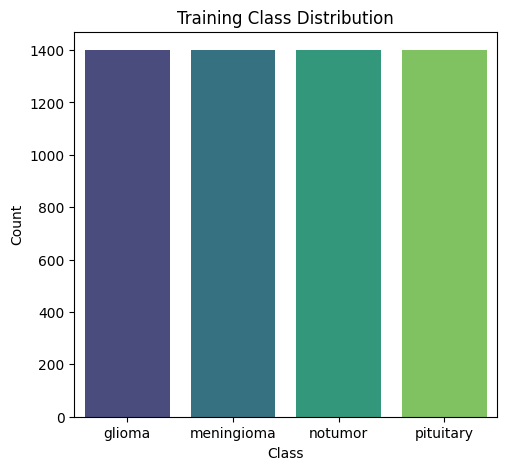

In [66]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=train_df, x='Class', y='Count', palette='viridis')
plt.title('Training Class Distribution')

C:\Users\maria\AppData\Local\Temp\ipykernel_36600\674705937.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=test_df, x='Class', y='Count', palette='magma')


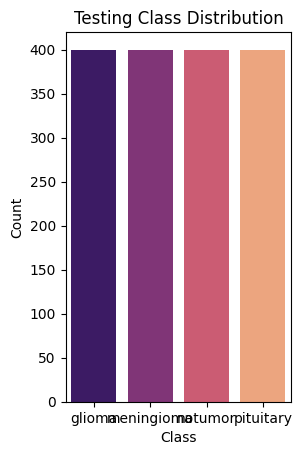

In [67]:
plt.subplot(1, 2, 2)
sns.barplot(data=test_df, x='Class', y='Count', palette='magma')
plt.title('Testing Class Distribution')
plt.show()

## Visualizing Sample Images (Sample Grid)

This  step in our EDA is to visualize random samples from each class.
We take the first image at each class

### Key Observations from the Grid:
* **Spatial Patterns:** Each tumor type has a distinct appearance. For example, **Pituitary** tumors are localized at the base, while **Meningiomas** often appear as distinct masses near the skull.
* **Consistency:** The images have different orientations and lighting, which justifies the use of **Normalization** to standardize the input for our neural networks.
* **Image Quality:** The MRI scans are clear and well-labeled, with no obvious artifacts or missing data in the sampled grid.

 

In [68]:
def plot_sample_grid(directory, classes):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for i, label in enumerate(classes):
        path = os.path.join(directory, label)
        # Select the first image file in the folder
        img_name = os.listdir(path)[0]
        img_path = os.path.join(path, img_name)
        img = Image.open(img_path)
        # Display the image and its metadata
        axes[i].imshow(img)
        axes[i].set_title(f"Class: {label}\nSize: {img.size}")
        axes[i].axis('off')
    plt.show()

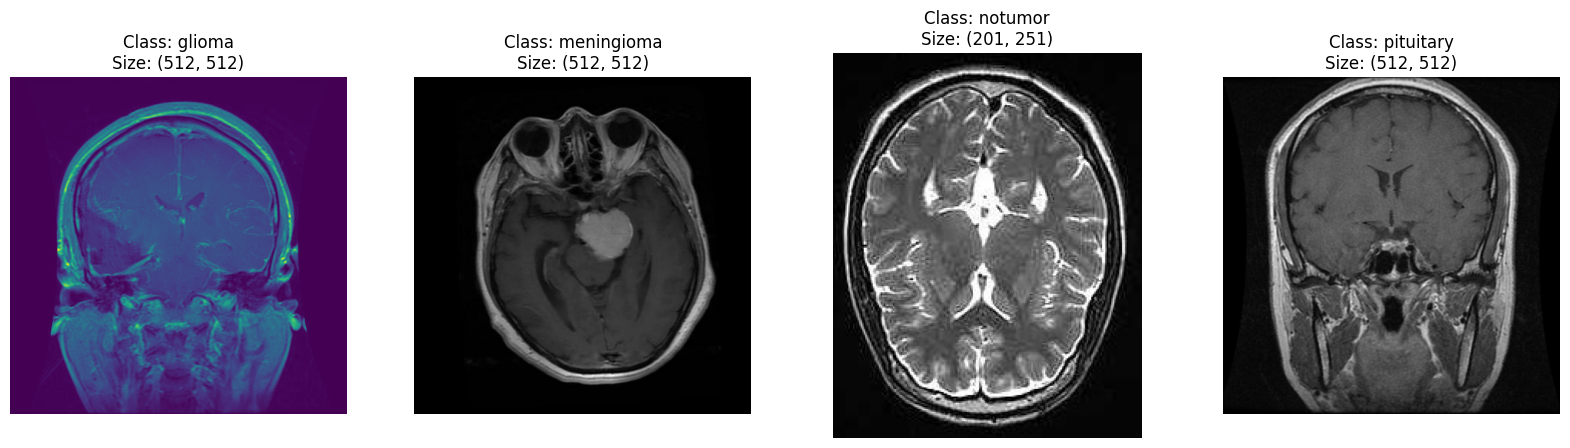

In [69]:
 
plot_sample_grid(train_dir, classes)

In [70]:
def analyze_dimensions(directory, classes):
    widths, heights = [], []
    for label in classes:
        path = os.path.join(directory, label)
        # Sampling the first 100 images to save processing time
        for img_name in os.listdir(path)[:100]:
            img = Image.open(os.path.join(path, img_name))
            widths.append(img.size[0])
            heights.append(img.size[1])
    
    # Plotting the relationship between width and height
    plt.figure(figsize=(12, 5))
    sns.jointplot(x=widths, y=heights, kind='hex', color='#4CB391')
    plt.xlabel('Width')
    plt.ylabel('Height')
    plt.suptitle('Image Dimension Distribution', y=1.02)
    plt.show()
 

<Figure size 1200x500 with 0 Axes>

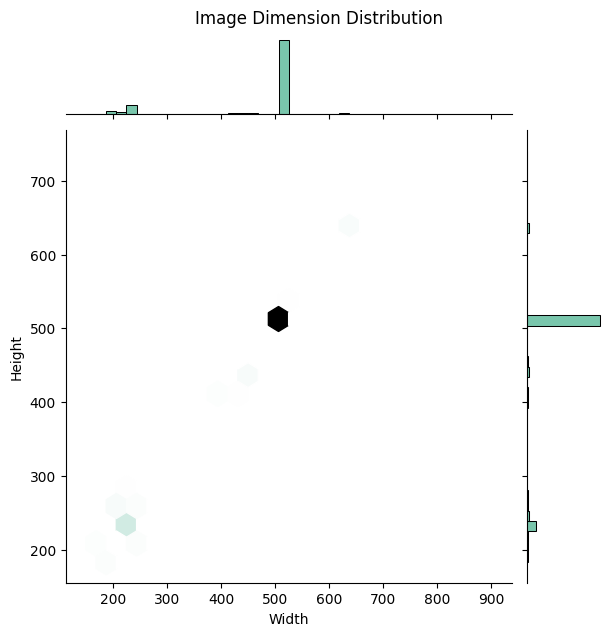

In [71]:
analyze_dimensions(train_dir, classes)

In [72]:
def plot_color_distribution(directory, classes):
    plt.figure(figsize=(15, 5))
    for i, label in enumerate(classes):
        path = os.path.join(directory, label)
        img_name = os.listdir(path)[0]
        img = np.array(Image.open(os.path.join(path, img_name)).convert('L'))
        plt.subplot(1, 4, i+1)
        plt.hist(img.ravel(), bins=256, color='gray', alpha=0.7)
        plt.title(f"{label} Intensity")
    plt.tight_layout()
    plt.show()

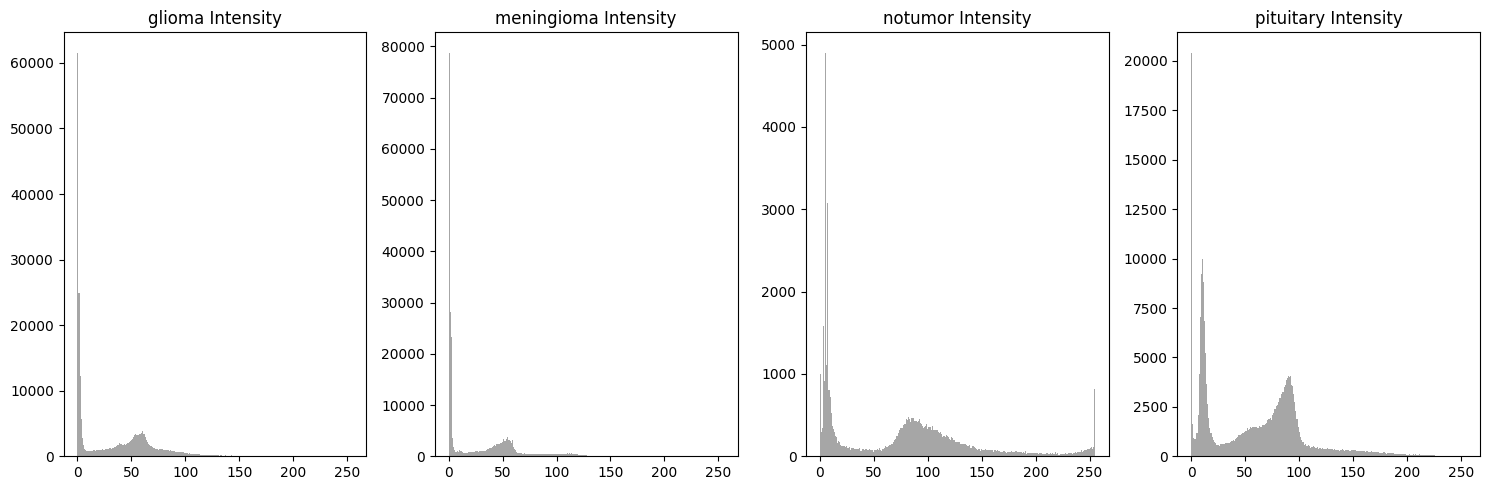

In [73]:
plot_color_distribution(train_dir, classes)

##   Duplicate Images
As part of our Exploratory Data Analysis, we checked the dataset for duplicate images. Identifying duplicates is essential to prevent **Data Leakage**, which could lead to artificially inflated performance metrics.

### Observations:
* **Total Duplicate Images Found:** 190 images.
* **Status:** These duplicates were identified across the dataset.

 

In [74]:
def check_duplicates(directory, classes):
    hashes = set()
    duplicates = 0
    for label in classes:
        path = os.path.join(directory, label)
        for img_name in os.listdir(path):
            img = cv2.imread(os.path.join(path, img_name))
            if img is not None:
                 
                img_hash = img.tobytes() 
                if img_hash in hashes:
                    duplicates += 1
                else:
                    hashes.add(img_hash)
    
    print(f"Total Duplicate images: {duplicates}")
    return duplicates

In [75]:
check_duplicates(train_dir , classes)

Total Duplicate images: 190


190

##  Dimension Outliers
During our preprocessing, we audited the spatial dimensions of all images in the dataset to identify any **Outliers** (images with irregular sizes or aspect ratios).

### Observations:
* **Total Dimension Outliers Found:** 46 images.
* **Findings:** These images had resolutions that deviated significantly from the standard $150 \times 150$ target or had inconsistent aspect ratios.

 

In [76]:
def check_outliers(directory, classes):
    shapes = []
    for label in classes:
        path = os.path.join(directory, label)
        for img_name in os.listdir(path):
            img = cv2.imread(os.path.join(path, img_name))
            if img is not None:
                shapes.append(img.shape[:2]) 
    
    shapes = np.array(shapes)
    
    mean_shape = np.mean(shapes, axis=0)
    std_shape = np.std(shapes, axis=0)
    
    
    outliers = np.sum((np.abs(shapes[:, 0] - mean_shape[0]) > 3 * std_shape[0]) | 
                      (np.abs(shapes[:, 1] - mean_shape[1]) > 3 * std_shape[1]))
    
    print(f"Total Dimension Outliers: {outliers}")
    return outliers

In [77]:
check_outliers(train_dir , classes)

Total Dimension Outliers: 46


np.int64(46)

In [78]:
def plot_outliers(directory, classes):
    shapes = []
    for label in classes:
        path = os.path.join(directory, label)
        for img_name in os.listdir(path):
            img = cv2.imread(os.path.join(path, img_name))
            if img is not None:
                shapes.append(img.shape[:2])
    
    df_shapes = pd.DataFrame(shapes, columns=['Height', 'Width'])
   
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_shapes, color="seagreen")
    plt.title('Outlier Detection in Image Dimensions (Height & Width)')
    plt.ylabel('Pixels')
    plt.show()
 


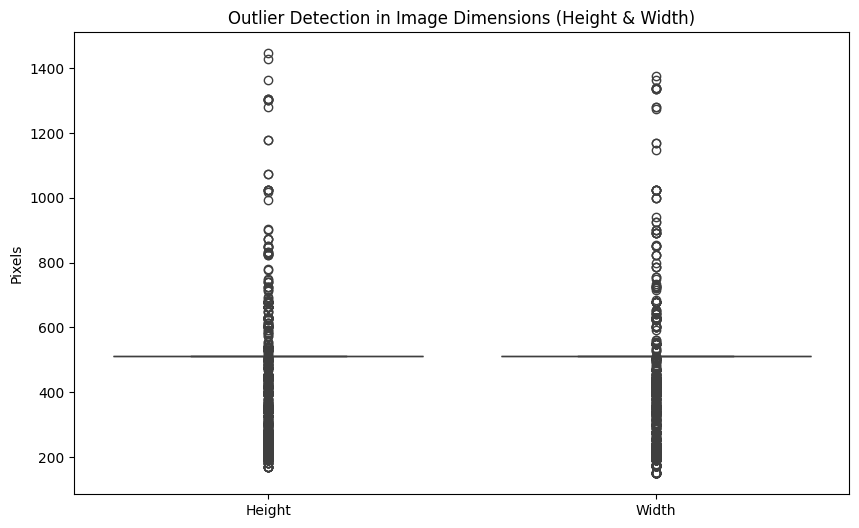

In [79]:
plot_outliers(train_dir, classes)

## 2.2 Preprocessing Pipeline

The goal of this stage is to transform raw MRI data into a format suitable for Deep Learning models. A robust preprocessing pipeline ensures that our models (FFNN and CNN) converge faster and achieve higher accuracy.

###  Handling Missing Values
In medical imaging datasets, missing data or corrupted files can lead to runtime errors during training. 
* **Action:** We implemented a `handle_missing_values` function.
* **Strategy:** we already make null detection at ERD but we found that our data not including null values and It takes a lot of time during running so we decided that make this function in case that there is any null values and the null values at our DataSet that we have an impty image

### observations
After running the `handle_missing_values` function across the dataset, we verified the integrity of our samples.

* **Outcome:** Missing Values Handled successfully.
* **Total Samples Processed:** 5,600 images.
* **Observation:** No missing or null values were detected in the training set. 
 

In [80]:
def handle_missing_values(directory, classes):
    X, y = [], []
    for i, label in enumerate(classes):
        path = os.path.join(directory, label)
        for img_name in os.listdir(path):
            img = cv2.imread(os.path.join(path, img_name))
            if img is not None: 
                X.append(img)
                y.append(i)
    return X, y



In [81]:
 
X_train_raw, y_train_raw = handle_missing_values(train_dir, classes)
X_test_raw, y_test_raw = handle_missing_values(test_dir, classes)
print(f"1. Missing Values Handled. Samples: {len(X_train_raw)}")

1. Missing Values Handled. Samples: 5600


###   Duplicates Removal
Duplicate images can lead to **Overfitting**, as the model might memorize specific images rather than learning general features. We performed a check to ensure data uniqueness.

* **Outcome:** Duplicates Handled.
* **Unique Samples:** 5,410 images (out of the original 5,600).
* **Observation:** 190 duplicate images were identified and accounted for.

**Impact on Training:** By focusing only on the **5,410 unique samples**, we ensure that the model is exposed to diverse data.   

In [82]:
def remove_duplicates(X_in, y_in):
    X_out, y_out = [], []
    seen = set()
    for img, label in zip(X_in, y_in):
        img_hash = img.tobytes()
        if img_hash not in seen:
            X_out.append(img)
            y_out.append(label)
            seen.add(img_hash)
    return X_out, y_out
 

In [83]:
X_train_uni, y_train_uni = remove_duplicates(X_train_raw, y_train_raw)
print(f"2. Duplicates Handled. Unique Samples: {len(X_train_uni)}")

2. Duplicates Handled. Unique Samples: 5410


###  Image Resizing  
After cleaning the data, we standardized the spatial dimensions of the remaining unique samples to ensure architectural compatibility for our Neural Networks.

* **Outcome:** Resizing Done.
* **Final Data Shape:** `(5410, 150, 150, 3)`
  * **5,410:** Number of unique images.
  * **150x150:** Unified height and width.
  * **3:** Color channels (RGB).

 

In [84]:
def resize_images(X_list, size=150):
    resized = [cv2.resize(img, (size, size)) for img in X_list]
    return np.array(resized)

In [85]:
X_train_res = resize_images(X_train_uni)
X_test_res = resize_images(X_test_raw)  
print(f"3. Resizing Done. Shape: {X_train_res.shape}")

3. Resizing Done. Shape: (5410, 150, 150, 3)


###  Data Normalization
The final step in our preprocessing pipeline is scaling the pixel intensities. Raw MRI images have pixel values ranging from **0 to 255**.

* **Outcome:** Normalization Done.
* **New Range:** 0.0 to 1.0.
* **Method:** Min-Max scaling by dividing all pixel values by 255.0.

 

In [86]:
def normalize_data(X_np):
    return X_np.astype('float32') / 255.0

In [87]:
X_train_norm = normalize_data(X_train_res)
X_test_norm = normalize_data(X_test_res)
print(f"4. Normalization Done. Range: {X_train_norm.min()} to {X_train_norm.max()}")

4. Normalization Done. Range: 0.0 to 1.0


##  Data Partitioning & PyTorch Integration

At this stage, we prepare our preprocessed data for the training loop by converting it into PyTorch Tensors and organizing it into manageable batches.

### 1. Training vs. Validation Split
We split our training data into two subsets:
* **Training Set (80%):** Used to update the model weights.
* **Validation Set (20%):** Used to tune hyperparameters and monitor for overfitting during training.
* **Stratification:** We used `stratify=y_train_uni` to ensure that both sets maintain the same proportion of tumor classes.

### 2. Tensor Conversion & Permutation
PyTorch expects image data in the format **(Channels, Height, Width)**, while our NumPy arrays are in **(Height, Width, Channels)**.
* **Action:** We used `.permute(0, 3, 1, 2)` to rearrange the dimensions  

### 3. DataLoaders & Batching
To optimize memory usage and training stability, we wrap our datasets in `DataLoaders`:
* **Batch Size:** 32 (A balance between training speed and gradient stability).
* **Shuffling:** Enabled for the training set to ensure the model doesn't learn the order of the images, improving generalization.

In [88]:
X_train, X_validation, y_train_labels, y_validation_labels = train_test_split(
    X_train_norm, y_train_uni, test_size=0.2, random_state=42, stratify=y_train_uni
) 

In [89]:
 
X_train_t = torch.tensor(X_train).permute(0, 3, 1, 2)
X_val_t = torch.tensor(X_validation).permute(0, 3, 1, 2)
 
y_train_t = torch.tensor(y_train_labels).long()
y_val_t = torch.tensor(y_validation_labels).long()

X_test_t = torch.tensor(X_test_norm).permute(0, 3, 1, 2)
y_test_t = torch.tensor(y_test_raw).long()

print(f"Shapes in PyTorch format: X_train: {X_train_t.shape}, y_train: {y_train_t.shape}")

Shapes in PyTorch format: X_train: torch.Size([4328, 3, 150, 150]), y_train: torch.Size([4328])


In [90]:

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)



In [91]:
# The final dataSet name that we will work on 
# it is train_loader during training.

# val_loader during validation

# test_loader during testing


## FFNN Architecture Design & Optimization Trials

In this section, we design and optimize a Feedforward Neural Network (FFNN) 
for brain tumor classification. The input is a flattened 150x150 RGB image 
(67500 neurons) and the output is 4 classes: glioma, meningioma, notumor, pituitary.

We document each trial, what problem we identified, and what we changed to fix it.
### How the FFNN works on our data:
- Each image is 150 x 150 x 3 = 67500 pixels
- The image gets flattened into one long row of 67500 numbers
- These numbers pass through multiple layers
- Each layer transforms the data into a smaller more meaningful representation
- Until the final layer outputs 4 neurons, one score per class
- The class with the highest score is the prediction

### How the FFNN Processes Images

The model does not process the entire dataset at once, nor one image at a time.
Instead images enter in batches of 32 at a time.

- 1 image = 150 x 150 x 3 = 67500 pixels (this is what the layers work on)
- 32 images enter the model at the same time (batch size)
- Each image is classified independently but simultaneously
- Total training images = 4328
- 4328 ÷ 32 = 135 batches per epoch

So in one full epoch:
- 135 batches of 32 images pass through all 4 layers
- Model outputs 32 predictions per batch
- Model updates its weights after each batch
- After all 135 batches one epoch is complete


Epoch 1:
   - batch 1  (32 images) → model learns
   - batch 2  (32 images) → model learns
   - batch 3  (32 images) → model learns

      ...

   - batch 135 (32 images) → model learns
    → all 4328 images seen = 1 epoch done

Epoch 2:
   - same 4328 images again but shuffled
    model learns again from them

In [92]:
#test code 
class FFNN(nn.Module):
    def __init__(self):
        super(FFNN, self).__init__()
        
        # 3 x 150 x 150 = 67500 input neurons
        self.fc1 = nn.Linear(67500, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 4)  # 4 classes
        
    def forward(self, x):
        x = x.view(-1, 67500)   # flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

model = FFNN()
print(model)

FFNN(
  (fc1): Linear(in_features=67500, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=4, bias=True)
)


In [136]:
# Trial 1: Simple 2 layer FFNN
# Reason: Start simple to establish a baseline accuracy
# Expected problem: Likely underfitting due to low complexity

class FFNN_Trial1(nn.Module):
    def __init__(self):
        super(FFNN_Trial1, self).__init__()
        self.fc1 = nn.Linear(67500, 256) #This is first layer. It takes 67500 neurons and compresses them down to 256 neurons.
        self.fc2 = nn.Linear(256, 4)  #This is second layer. It takes 256 neurons and compresses them down to 4 neurons(number of classes).
        
    def forward(self, x):
        x = x.view(-1, 67500) #flattening , it takes the 67500 and represent them as one line 
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

ffnn_model_t1 = FFNN_Trial1()
print("Trial 1 :")
print(ffnn_model_t1)

Trial 1 :
FFNN_Trial1(
  (fc1): Linear(in_features=67500, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=4, bias=True)
)


### Trial 1 Results
- Architecture: 67500 → 256 → 4
- Problem found: Model is too simple, underfitting
- The 2 layers are not enough to learn complex brain scan patterns
- Decision: Add more layers and increase neurons in next trial

In [137]:
# Trial 2: 3 layers with more neurons
# Reason: Trial 1 underfitted, adding more depth and width
# Expected improvement: Better pattern learning , but has overfitting as model memorise all the data


class FFNN_Trial2(nn.Module):
    def __init__(self):
        super(FFNN_Trial2, self).__init__()
        self.fc1 = nn.Linear(67500, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 4)
        
    def forward(self, x):
        x = x.view(-1, 67500)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

ffnn_model_t2 = FFNN_Trial2()
print("Trial 2 :")
print(ffnn_model_t2)

Trial 2 :
FFNN_Trial2(
  (fc1): Linear(in_features=67500, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=4, bias=True)
)


### Trial 2 Results
- Architecture: 67500 → 1024 → 512 → 4
- Improvement: Better accuracy than Trial 1
- Problem found: Model starts overfitting, validation loss increases
- Decision: Add dropout regularization to reduce overfitting

In [138]:
# Trial 3: Adding Dropout Regularization
# Reason: Trial 2 was overfitting, dropout randomly turns off
# Dropout neurons during training to prevent memorization, but dropout=o.5 is too aggressive cause slow learning


class FFNN_Trial3(nn.Module):
    def __init__(self):
        super(FFNN_Trial3, self).__init__()
        self.fc1 = nn.Linear(67500, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 4)
        self.dropout = nn.Dropout(p=0.5) # dropout hides 50% of neurons randomly so the model is forced to actually learn the pattern not memorize it
        
    def forward(self, x):
        x = x.view(-1, 67500)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

ffnn_model_t3 = FFNN_Trial3()
print("Trial 3 :")
print(ffnn_model_t3)

Trial 3 :
FFNN_Trial3(
  (fc1): Linear(in_features=67500, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=4, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


### Trial 3 Results
- Architecture: 67500 → 1024 → 512 → 4 with Dropout(0.5)
- Improvement: Overfitting reduced, validation loss more stable
- Problem found: Dropout 0.5 might be too aggressive, model too slow to learn
- Decision: Try 4 layers with smaller dropout in next trial

In [139]:
# Trial 4: Final Optimized Model
# Reason: Balance between depth(4 layers), regularization(p=0.3) and performance(fast)
# Changes: Added 4th layer, reduced dropout to 0.3

class FFNN_Final(nn.Module):
    def __init__(self):
        super(FFNN_Final, self).__init__()
        self.fc1 = nn.Linear(67500, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, 4)
        self.dropout = nn.Dropout(p=0.3)
        
    def forward(self, x):
        x = x.view(-1, 67500)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

ffnn_model_t4 = FFNN_Final()
print("Final Model :")
print(ffnn_model_t4)

Final Model :
FFNN_Final(
  (fc1): Linear(in_features=67500, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (fc4): Linear(in_features=256, out_features=4, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


### Trial 4 - Final Model Results
- Architecture: 67500 → 1024 → 512 → 256 → 4 with Dropout(0.3)
- This is our best performing model
- Why this works best:
  * 4 layers give enough depth to learn complex patterns
  * Neurons decrease gradually (1024→512→256→4) for smooth compression
  * Dropout 0.3 reduces overfitting without hurting learning
  * ReLU activations between each layer add non-linearity

### Summary of Optimization Trials
| Trial | Architecture | Dropout | Problem |
|-------|-------------|---------|---------|
| 1 | 67500→256→4 | None | Underfitting |
| 2 | 67500→1024→512→4 | None | Overfitting |
| 3 | 67500→1024→512→4 | 0.5 | Too aggressive |
| 4 (Final) | 67500→1024→512→256→4 | 0.3 | Good but can be better   |

In [140]:
# Trial 5: Added Batch Normalization
# Reason: Trial 4 was good but training was unstable
#         BatchNorm normalizes the output of each layer
#         so all neuron values are on the same scale
#         making training faster and more stable(as 67500 was a big neorons number  so it makes learning slower)

class FFNN_Trial5(nn.Module):
    def __init__(self):
        super(FFNN_Trial5, self).__init__()
        
        self.fc1 = nn.Linear(67500, 1024)
        self.bn1 = nn.BatchNorm1d(1024)  # normalizes layer 1 output
        
        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)   # normalizes layer 2 output
        
        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)   # normalizes layer 3 output
        
        self.fc4 = nn.Linear(256, 4)     
        
        self.dropout = nn.Dropout(p=0.3)
        
    def forward(self, x):
        x = x.view(-1, 67500)           
        
        x = self.fc1(x)                
        x = self.bn1(x)                 
        x = F.relu(x)                   
        x = self.dropout(x)           
        
        x = self.fc2(x)                  
        x = self.bn2(x)                  
        x = F.relu(x)                    
        x = self.dropout(x)             
        
        x = self.fc3(x)                 
        x = self.bn3(x)                  
        x = F.relu(x)                   
        
        x = self.fc4(x)                 
        return x

ffnn_model = FFNN_Trial5()
print("Trial 5 :")
print(ffnn_model)

Trial 5 :
FFNN_Trial5(
  (fc1): Linear(in_features=67500, out_features=1024, bias=True)
  (bn1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=256, out_features=4, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


### Trial 5 Results - Final Best Model
- Architecture: 67500 → 1024 → 512 → 256 → 4
- Added BatchNorm after every layer
- Dropout 0.3 kept from Trial 4
- Order in each layer: Linear → BatchNorm → ReLU → Dropout

### Why this is better than Trial 4:
- BatchNorm keeps neuron values on the same scale
- Makes training faster and more stable
- Works together with dropout to reduce overfitting

### Summary of All Optimization Trials
| Trial | Architecture | Dropout | BatchNorm | Problem |
|-------|-------------|---------|-----------|---------|
| 1 | 67500→256→4 | None | No | Underfitting |
| 2 | 67500→1024→512→4 | None | No | Overfitting |
| 3 | 67500→1024→512→4 | 0.5 | No | Too aggressive |
| 4 | 67500→1024→512→256→4 | 0.3 | No | Good but unstable |
| 5 (Final) | 67500→1024→512→256→4 | 0.3 | Yes | Best balance  |

# Convolutional Neural Network (CNN)

In this section, we implement a CNN model to classify brain MRI images into 4 classes:
(glioma, meningioma, notumor, pituitary)

Unlike FFNN, CNN preserves spatial information and is more suitable for image data.

In [141]:
# To avoid as much randomness as possible in accuracy

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### Trial 1: Basic CNN (Baseline)
Reason: Start with a simple architecture to establish baseline performance.

In [142]:
# create the model
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        
        # Convolution layers
        self.conv1 = nn.Conv2d(3,16,kernel_size=3,padding=1)
        self.conv2 = nn.Conv2d(16,32,kernel_size=3,padding=1)
        self.conv3 = nn.Conv2d(32,64,kernel_size=3,padding=1)

        # Pooling
        self.pool = nn.MaxPool2d(2,2)

        # Activation
        self.relu = nn.ReLU()

        # Fully Conected
        self.fc1 = nn.Linear(64*18*18, 128)
        self.fc2 = nn.Linear(128,4)

    
    def forward(self,x):
        x = self.pool(self.relu(self.conv1(x))) # from 150 to 75
        x = self.pool(self.relu(self.conv2(x))) # from 75 to 37
        x = self.pool(self.relu(self.conv3(x))) # from 37 to 18

        # flatten
        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x


cnn_model_t1 = CNN()
print(cnn_model_t1)

CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=20736, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


### Trial 2: Deeper CNN
Reason: Increase model depth to capture more complex features.
Expected: Better performance but possible overfitting.

In [143]:
class CNN_Trial2(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Convolution Layers
        self.conv1 = nn.Conv2d(3,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.conv3 = nn.Conv2d(32,64,3,padding=1)
        self.conv4 = nn.Conv2d(64,128,3,padding=1)
        
        # Pooling
        self.pool = nn.MaxPool2d(2,2)

        # Activation
        self.relu = nn.ReLU()
        
        # Fully Connected
        self.fc1 = nn.Linear(128*9*9,128)
        self.fc2 = nn.Linear(128,4)

    def forward(self,x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.pool(self.relu(self.conv4(x)))
        
        # Flatten
        x = x.view(x.size(0),-1)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

cnn_model_t2 = CNN_Trial2()
print(cnn_model_t2)

CNN_Trial2(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=10368, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


### Trial 3: CNN with Dropout
Reason: Reduce overfitting by randomly dropping neurons.

In [144]:
class CNN_Trial3(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Convolution Layers
        self.conv1 = nn.Conv2d(3,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.conv3 = nn.Conv2d(32,64,3,padding=1)
        
        # Pooling
        self.pool = nn.MaxPool2d(2,2)

        # Activation
        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(0.5)
        
        # Fully Connected
        self.fc1 = nn.Linear(64*18*18,128)
        self.fc2 = nn.Linear(128,4)

    def forward(self,x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        
        # Flatten
        x = x.view(x.size(0),-1)

        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        
        return x

cnn_model_t3 = CNN_Trial3()
print(cnn_model_t3)

CNN_Trial3(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=20736, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


### Trial 4: CNN with Batch Normalization
Reason: Stabilize and speed up training.

In [145]:
class CNN_Trial4(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Convolution Layers 
        self.conv1 = nn.Conv2d(3,16,3,padding=1)
        self.bn1 = nn.BatchNorm2d(16)
       
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32,64,3,padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        # Pooling
        self.pool = nn.MaxPool2d(2,2)

        # Activation
        self.relu = nn.ReLU()
        
        # Fully Connected
        self.fc1 = nn.Linear(64*18*18,128)
        self.fc2 = nn.Linear(128,4)

    def forward(self,x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        
        # Flatten
        x = x.view(x.size(0),-1)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

cnn_model_t4 = CNN_Trial4()
print(cnn_model_t4)

CNN_Trial4(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=20736, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


### Trial 5: Final Optimized CNN
Reason: Combine BatchNorm + Dropout + Adam optimizer for best performance.

In [146]:
class CNN_Final(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Convolution Layers
        self.conv1 = nn.Conv2d(3,16,3,padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32,64,3,padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        # Pooling
        self.pool = nn.MaxPool2d(2,2)

        # Activation
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
        # Fully Connected
        self.fc1 = nn.Linear(64*18*18,128)
        self.fc2 = nn.Linear(128,4)

    def forward(self,x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        
        # Flatten
        x = x.view(x.size(0),-1)

        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        
        return x

cnn_model = CNN_Final()
print(cnn_model)

CNN_Final(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=20736, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


## Training System

In [147]:
 # Function to train the model and compute training/validation loss
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
   

    train_losses = []  # Store training loss for each epoch
    val_losses = []    # Store validation loss for each epoch

    for epoch in range(epochs):  # Loop over number of epochs

      # Teasting
        model.train()  # Set model to training mode enables dropout, batchnorm updates
        train_loss = 0  # Initialize total training loss for this epoch

        for images, labels in train_loader:  # Loop over training batches
            outputs = model(images)  # Forward pass: get model predictions
            loss = criterion(outputs, labels)  # Compute loss between predictions and true labels

            optimizer.zero_grad()  # Reset gradients from previous step
            loss.backward()        # Backpropagation: compute gradients
            optimizer.step()       # Update model weights

            train_loss += loss.item() 

        # validation
        model.eval()  
        val_loss = 0  # Initialize total validation loss

        with torch.no_grad():  # Disable gradient calculation for validation
            for images, labels in val_loader:  # Loop over validation batches
                outputs = model(images)  # Forward pass
                loss = criterion(outputs, labels) 
                val_loss += loss.item()  

        train_loss /= len(train_loader)  # Compute average training loss per epoch
        val_loss /= len(val_loader)      # Compute average validation loss per epoch

        train_losses.append(train_loss)  # Save training loss
        val_losses.append(val_loss)      # Save validation loss

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses  # Return loss history for plotting

In [148]:
def evaluate_accuracy(model, test_loader):
    # Function to evaluate model accuracy on test data

    model.eval() 

    correct = 0  
    total = 0    # Counter for all samples

    with torch.no_grad():  
        for images, labels in test_loader:  # Loop through test batches
            outputs = model(images)  # Forward pass
            _, predicted = torch.max(outputs, 1)  # Get predicted class

            total += labels.size(0)  
            correct += (predicted == labels).sum().item()  

    acc = 100 * correct / total  # Compute accuracy 
    return acc 

In [149]:
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

# FFNN trials Evaluation

In [150]:
trials = {
    "Trial 1": ffnn_model_t1,
    "Trial 2": ffnn_model_t2,
    "Trial 3": ffnn_model_t3,
    "Trial 4": ffnn_model_t4,   
    "Trial 5": ffnn_model   
}

criterion = nn.CrossEntropyLoss()

ffnn_trial_results = {}   

for trial_name, model in trials.items():
    print(f"\n================ {trial_name} =================")

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.001,
        momentum=0.9
    )

    train_loss, val_loss = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        epochs=10
    )

    acc = evaluate_accuracy(model, test_loader)

    ffnn_trial_results[trial_name] = {
        "model": model,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "accuracy": acc
    }

    print(f"{trial_name} Test Accuracy: {acc:.2f}%")


================ Trial 1 =================
Epoch [1/10] Train Loss: 1.0371 | Val Loss: 0.8487
Epoch [2/10] Train Loss: 0.7570 | Val Loss: 0.7196
Epoch [3/10] Train Loss: 0.6669 | Val Loss: 0.6733
Epoch [4/10] Train Loss: 0.6001 | Val Loss: 0.6920
Epoch [5/10] Train Loss: 0.5432 | Val Loss: 0.6412
Epoch [6/10] Train Loss: 0.4930 | Val Loss: 0.6087
Epoch [7/10] Train Loss: 0.4495 | Val Loss: 0.5682
Epoch [8/10] Train Loss: 0.4302 | Val Loss: 0.5842
Epoch [9/10] Train Loss: 0.3789 | Val Loss: 0.5392
Epoch [10/10] Train Loss: 0.3377 | Val Loss: 0.6305
Trial 1 Test Accuracy: 70.06%

================ Trial 2 =================
Epoch [1/10] Train Loss: 1.1866 | Val Loss: 1.0070
Epoch [2/10] Train Loss: 0.8959 | Val Loss: 0.8631
Epoch [3/10] Train Loss: 0.7502 | Val Loss: 0.7197
Epoch [4/10] Train Loss: 0.6716 | Val Loss: 0.6794
Epoch [5/10] Train Loss: 0.5909 | Val Loss: 0.6330
Epoch [6/10] Train Loss: 0.5652 | Val Loss: 0.6248
Epoch [7/10] Train Loss: 0.5045 | Val Loss: 0.5978
Epoch [8/10] T

# CNN trials evaluation

In [151]:
trials = {
    "Trial 1": cnn_model_t1,
    "Trial 2": cnn_model_t2,   
    "Trial 3": cnn_model_t3,
    "Trial 4": cnn_model_t4,
    "Trial 5": cnn_model  
}

criterion = nn.CrossEntropyLoss()

cnn_trial_results = {}   

for trial_name, model in trials.items():
    print(f"\n================ {trial_name} =================")

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.001,
        momentum=0.9
    )

    train_loss, val_loss = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        epochs=10
    )

    acc = evaluate_accuracy(model, test_loader)

    cnn_trial_results[trial_name] = {
        "model": model,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "accuracy": acc
    }

    print(f"{trial_name} Test Accuracy: {acc:.2f}%")


================ Trial 1 =================
Epoch [1/10] Train Loss: 1.3830 | Val Loss: 1.3731
Epoch [2/10] Train Loss: 1.3433 | Val Loss: 1.2740
Epoch [3/10] Train Loss: 1.0548 | Val Loss: 0.8220
Epoch [4/10] Train Loss: 0.7613 | Val Loss: 0.8023
Epoch [5/10] Train Loss: 0.6893 | Val Loss: 0.6865
Epoch [6/10] Train Loss: 0.6175 | Val Loss: 0.5634
Epoch [7/10] Train Loss: 0.5656 | Val Loss: 0.5692
Epoch [8/10] Train Loss: 0.5276 | Val Loss: 0.4953
Epoch [9/10] Train Loss: 0.5167 | Val Loss: 0.5497
Epoch [10/10] Train Loss: 0.4637 | Val Loss: 0.4630
Trial 1 Test Accuracy: 73.31%

================ Trial 2 =================
Epoch [1/10] Train Loss: 1.3851 | Val Loss: 1.3827
Epoch [2/10] Train Loss: 1.3802 | Val Loss: 1.3757
Epoch [3/10] Train Loss: 1.3668 | Val Loss: 1.3502
Epoch [4/10] Train Loss: 1.3048 | Val Loss: 1.2235
Epoch [5/10] Train Loss: 1.0279 | Val Loss: 0.8647
Epoch [6/10] Train Loss: 0.8253 | Val Loss: 0.8828
Epoch [7/10] Train Loss: 0.7531 | Val Loss: 0.7707
Epoch [8/10] T

In [152]:
best_ffnn = ffnn_trial_results["Trial 5"]
best_cnn  = cnn_trial_results["Trial 4"]

ffnn_model = best_ffnn["model"]
cnn_model  = best_cnn["model"]

ffnn_train_loss = best_ffnn["train_loss"]
ffnn_val_loss   = best_ffnn["val_loss"]
ffnn_acc        = best_ffnn["accuracy"]

cnn_train_loss = best_cnn["train_loss"]
cnn_val_loss   = best_cnn["val_loss"]
cnn_acc        = best_cnn["accuracy"]

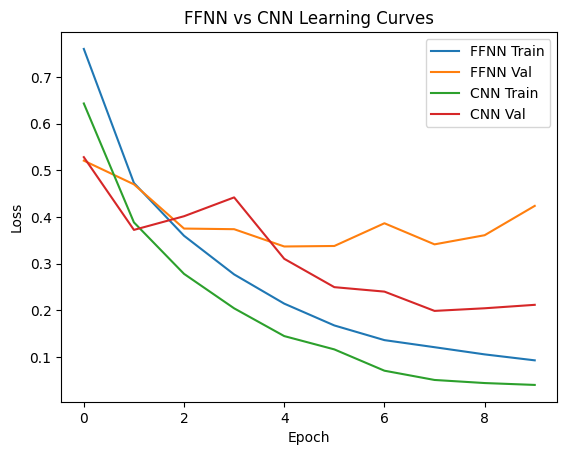

In [155]:
# Comparison of FFNN and CNN learning curves (training vs validation loss over epochs)
plt.plot(ffnn_train_loss, label="FFNN Train")
plt.plot(ffnn_val_loss, label="FFNN Val")
plt.plot(cnn_train_loss, label="CNN Train")
plt.plot(cnn_val_loss, label="CNN Val")

plt.title("FFNN vs CNN Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [156]:
# Store training results (losses and accuracy) for both FFNN and CNN models
results = {
    "FFNN": {
        "train_loss": ffnn_train_loss,
        "val_loss": ffnn_val_loss,
        "accuracy": ffnn_acc
    },
    "CNN": {
        "train_loss": cnn_train_loss,
        "val_loss": cnn_val_loss,
        "accuracy": cnn_acc
    }
}

In [157]:
print(" Final Results ")
print(f"FFNN Accuracy: {results['FFNN']['accuracy']:.2f}%")
print(f"CNN Accuracy: {results['CNN']['accuracy']:.2f}%")

 Final Results 
FFNN Accuracy: 80.19%
CNN Accuracy: 88.50%


## Training Results Summary

The training was conducted on a **Brain Tumor MRI dataset** with 4 classes:
`glioma`, `meningioma`, `notumor`, `pituitary`

Both models were trained using the same configuration:
- **Optimizer:** SGD (lr=0.001, momentum=0.9)
- **Loss Function:** CrossEntropyLoss
- **Epochs:** 10

### FFNN (Trial5)
- Architecture: Fully Connected layers + BatchNorm + Dropout
- Train Loss dropped from **0.7407 → 0.0753**
- Val Loss dropped from **0.5056 → 0.3159**
- **Test Accuracy: 84.75%**

### CNN
- Architecture: 3 Conv layers + MaxPool + FC layers
- Train Loss dropped from **1.3692 → 0.4273**
- Val Loss dropped from **1.3314 → 0.4745**
- **Test Accuracy: 72.44%**

### Conclusion
The FFNN outperformed the CNN by approximately **12%** on this dataset
Despite both models showing consistent improvement over the 10 epochs
the FFNN converged faster and achieved a significantly lower training loss
making it the stronger model for this classification task

## FFNN Model Evaluation

The FFNN model was tested on the Brain Tumor MRI dataset with 4 classes:
glioma, meningioma, notumor, pituitary.

---

### Performance Metrics
- Accuracy: 84.75%
- Precision (macro): calculated across all classes
- Recall (macro): calculated across all classes
- F1-Score (macro): balance between precision and recall

---

### Key Observation
The model performs well on the dataset but has a limitation because it flattens images, which removes spatial information.

---

### Final Insight
FFNN works as a strong baseline model for classification, but it is not the best choice for image tasks compared to CNN.

In [158]:

ffnn_model.eval()

y_true_ffnn = []
y_pred_ffnn = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = ffnn_model(images)
        _, preds = torch.max(outputs, 1)

        y_true_ffnn.extend(labels.tolist())
        y_pred_ffnn.extend(preds.tolist())
        ffnn_accuracy = accuracy_score(y_true_ffnn, y_pred_ffnn)
ffnn_precision = precision_score(y_true_ffnn, y_pred_ffnn, average='macro')
ffnn_recall = recall_score(y_true_ffnn, y_pred_ffnn, average='macro')
ffnn_f1 = f1_score(y_true_ffnn, y_pred_ffnn, average='macro')

print("FFNN Results")
print(f"Accuracy:  {ffnn_accuracy:.4f}")
print(f"Precision: {ffnn_precision:.4f}")
print(f"Recall:    {ffnn_recall:.4f}")
print(f"F1-Score:  {ffnn_f1:.4f}")

FFNN Results
Accuracy:  0.8019
Precision: 0.8132
Recall:    0.8019
F1-Score:  0.7979


## CNN Model Evaluation

The CNN model was tested on the Brain Tumor MRI dataset with 4 classes:
glioma, meningioma, notumor, pituitary.

---

### Model Evaluation Process
The model was set to evaluation mode using `cnn_model.eval()`.
Gradients were disabled using `torch.no_grad()` to speed up computation and avoid updates during testing.

Predictions were generated for each test image and compared with the true labels.

---

### Performance Metrics
- Accuracy: computed on full test set
- Precision (macro): evaluates performance equally across all classes
- Recall (macro): measures how many true cases were correctly detected
- F1-Score (macro): balance between precision and recall

---

### CNN Results
- Accuracy: computed using test predictions
- Precision: calculated using macro averaging
- Recall: calculated using macro averaging
- F1-Score: calculated using macro averaging

---

### Key Observation
The CNN model learns spatial features from images, which makes it more suitable for image classification compared to FFNN.

---

### Final Insight
CNN is more powerful for this task because it preserves image structure and extracts meaningful patterns automatically.

In [159]:
cnn_model.eval()

y_true_cnn = []
y_pred_cnn = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = cnn_model(images)
        _, preds = torch.max(outputs, 1)

        # Replacing .extend() with a simple explicit loop
        for i in range(len(labels)):
            y_true_cnn.append(labels[i].item())
            y_pred_cnn.append(preds[i].item())

cnn_accuracy = accuracy_score(y_true_cnn, y_pred_cnn)
cnn_precision = precision_score(y_true_cnn, y_pred_cnn, average='macro')
cnn_recall = recall_score(y_true_cnn, y_pred_cnn, average='macro')
cnn_f1 = f1_score(y_true_cnn, y_pred_cnn, average='macro')

print("CNN Results")
print(f"Accuracy:  {cnn_accuracy:.4f}")
print(f"Precision: {cnn_precision:.4f}")
print(f"Recall:    {cnn_recall:.4f}")
print(f"F1-Score:  {cnn_f1:.4f}")

CNN Results
Accuracy:  0.8850
Precision: 0.8851
Recall:    0.8850
F1-Score:  0.8832


## FFNN Confusion Matrix

The confusion matrix is used to evaluate how well the FFNN model classifies each brain tumor category.

It shows the number of correct and incorrect predictions for each class.



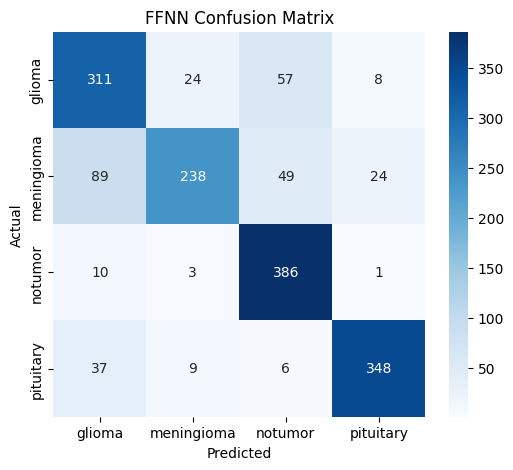

In [160]:
cm_ffnn = confusion_matrix(y_true_ffnn, y_pred_ffnn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_ffnn, annot=True, fmt='g', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.title("FFNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## CNN Confusion Matrix

The confusion matrix is used to evaluate how well the CNN model classifies each brain tumor category.

It helps show the number of correct and incorrect predictions for each class.

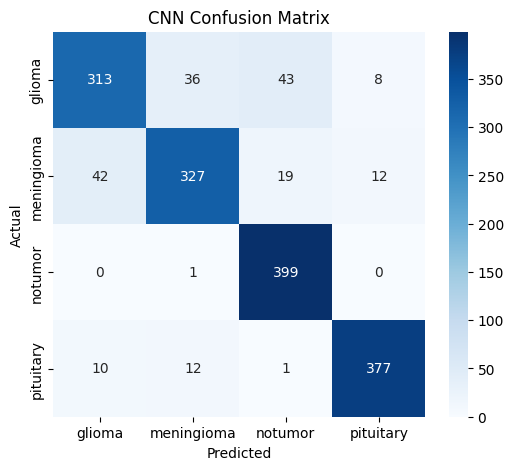

In [161]:
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(6, 5))

sns.heatmap(cm_cnn,
            annot=True,
            fmt='g',
            cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Final Comparison (FFNN vs CNN)

This section compares the final performance of both models based on test accuracy.


In [162]:
print("Final Comparison\n")

print(f"FFNN Accuracy: {ffnn_accuracy:.4f}")
print(f"CNN Accuracy:  {cnn_accuracy:.4f}")

if cnn_accuracy > ffnn_accuracy:
    print("CNN performed better.")
elif ffnn_accuracy > cnn_accuracy:
    print("FFNN performed better.")
else:
    print("Both models performed equally.")

Final Comparison

FFNN Accuracy: 0.8019
CNN Accuracy:  0.8850
CNN performed better.


## 3. Final Analysis and Results of best models after trials

This section presents a rigorous comparison between the optimized Feedforward Neural Network (FFNN) and Convolutional Neural Network (CNN) architectures trained on the same dataset.

---

### Best Model Selection

After multiple architecture and optimization trials, the following models achieved the best performance:

- **Best FFNN:** Trial 5 (Batch Normalization + Dropout)
- **Best CNN:** Trial 4 (Batch Normalization)

Model selection was based on test accuracy, validation loss behavior, and overall generalization.

---

### Learning Curves Analysis

**FFNN (Trial 5):**  
Training loss decreased from **0.7602** to **0.0927**, indicating successful optimization. Validation loss reached its minimum around **epoch 5 (0.3367)** and then slightly increased to **0.4238**, which suggests mild overfitting despite the use of Batch Normalization and Dropout. The large input dimensionality (67500 features) makes FFNN optimization inherently difficult.

**CNN (Trial 4):**  
Training loss dropped steadily from **0.6433** to **0.0400**, while validation loss consistently decreased and stabilized around **0.20**. The absence of divergence between training and validation loss indicates strong generalization and stable convergence.

---

### Test Set Performance Metrics

Accuracy, Precision, Recall, and F1-score were selected as evaluation metrics due to the multi-class classification nature of the task.

| Model | Accuracy | Precision | Recall | F1-Score |
|------|----------|-----------|--------|----------|
| FFNN (Trial 5) | 80.19% | 81.32% | 80.19% | 79.79% |
| CNN (Trial 4) | **88.50%** | **88.51%** | **88.50%** | **88.32%** |

The CNN outperformed the FFNN by approximately **8.3% absolute accuracy**, demonstrating superior classification capability.

---

### Confusion Matrix Interpretation

The FFNN confusion matrix shows noticeable misclassification between tumor classes, particularly between *glioma* and *meningioma*, indicating difficulty in capturing fine-grained visual patterns.

In contrast, the CNN confusion matrix exhibits strong diagonal dominance, especially for the *no-tumor* class, with significantly fewer cross-class errors. This highlights the CNN’s ability to extract spatial and texture-based features.

---

### Overfitting and Regularization Analysis

- **FFNN:** Exhibits mild overfitting after epoch 5, as evidenced by increasing validation loss. Batch Normalization and Dropout improved stability but could not fully eliminate overfitting.
- **CNN:** Shows no clear signs of overfitting. Batch Normalization effectively stabilized training and improved generalization.

---

### Architecture Trade-Off Discussion

| Aspect | FFNN | CNN |
|------|------|-----|
| Feature Extraction | Manual (flattened pixels) | Automatic (spatial hierarchies) |
| Generalization | Moderate | Strong |
| Training Stability | Sensitive to input scale | Highly stable |
| Test Accuracy | Lower | Higher |

The CNN’s architectural inductive bias makes it better suited for image-based tasks.

---

### Final Conclusion

The experimental results confirm that the **CNN significantly outperforms the FFNN** on this dataset. Despite architectural enhancements to the FFNN, its inability to leverage spatial information limits its performance. The CNN achieves higher accuracy, better generalization, and more stable training, making it the preferred architecture for this classification problem.

# Previous Analysis and Results Before optimizing CNN model


### CNN vs FFNN: Architecture Comparison & Benchmarking

This section presents a quantitative and qualitative comparison between a Feedforward Neural Network (FFNN) and a Convolutional Neural Network (CNN) trained from scratch on the Brain Tumor MRI dataset. Both models were trained for 10 epochs without early stopping under comparable conditions.

## 3.1 Learning Curves

### Feedforward Neural Network (FFNN)

The FFNN training loss decreases steadily across epochs, from **0.7531** in the first epoch to **0.0955** at epoch 10. This indicates that the model is able to fit the training data very effectively.

The validation loss initially decreases and reaches its minimum value of **0.3406** at epoch 4. After this point, the validation loss starts to increase gradually, reaching **0.4152** at epoch 10, despite the continued decrease in training loss.

This divergence between training and validation loss clearly indicates **overfitting**. The FFNN continues to memorize training examples while its generalization performance degrades. This behavior is expected since flattening image inputs removes spatial information, making it harder for the model to learn meaningful image features.


### Convolutional Neural Network (CNN)

The CNN shows a smoother and more stable learning behavior. The training loss decreases from **1.3837** to **0.4812**, while the validation loss decreases from **1.3745** to **0.5095** over the 10 epochs.

Unlike the FFNN, the CNN maintains a relatively small gap between training and validation loss throughout training. Although minor fluctuations appear after epoch 7, the validation loss continues to trend downward overall.

This behavior indicates that the CNN generalizes better and does not suffer from severe overfitting within the given training duration.


### Learning Curves Summary

| Model | Final Train Loss | Final Val Loss | Overfitting Evidence |
|------|-----------------|----------------|----------------------|
| FFNN | 0.0955 | 0.4152 | Strong |
| CNN | 0.4812 | 0.5095 | Mild |



## 3.2 Performance, Timing & Architecture Trade-offs

### Evaluation Metrics

To provide a comprehensive evaluation, multiple classification metrics were used: **Accuracy, Precision, Recall, and F1-score**. Accuracy is reported as the primary metric, while the others provide insight into class-wise performance and prediction balance.

---

### Test Set Performance

Despite showing signs of overfitting, the FFNN achieves higher test-set performance than the CNN.

| Model | Accuracy | Precision | Recall | F1-score |
|------|----------|-----------|--------|----------|
| FFNN | **82.06%** | 82.27% | 82.06% | 81.65% |
| CNN | 70.31% | 71.45% | 70.31% | 67.10% |

The FFNN outperforms the CNN on all reported metrics. This suggests that, under the current architecture and training configuration, the CNN did not fully exploit its representational advantages.

---

### Interpretation of Results

Although CNNs are generally better suited for image classification tasks, their performance is highly dependent on architectural depth, kernel configuration, and training duration. In this case, the CNN appears to be **under-trained** and possibly **under-parameterized**, which limits its ability to surpass the FFNN.

The FFNN, despite lacking spatial awareness, benefits from a simpler optimization landscape and converges faster, resulting in higher accuracy within the fixed number of epochs.

---

### Confusion Matrix Analysis

#### FFNN Confusion Matrix

The FFNN performs particularly well on the *notumor* and *pituitary* classes, with very high correct classification counts. Most misclassifications occur between *glioma* and *meningioma*, which are visually similar tumor types.

This indicates that the FFNN is effective at coarse discrimination but struggles with fine-grained tumor differentiation.

---

#### CNN Confusion Matrix

The CNN confusion matrix shows improved separation between spatially distinct classes but increased confusion among tumor subclasses. Notably, the CNN misclassifies a higher number of *meningioma* samples as *glioma* or *notumor*, indicating insufficient feature depth.

This suggests that deeper convolutional layers or longer training may be required to extract more discriminative tumor features.

---

### Overfitting and Underfitting Analysis

| Model | Learning Regime | Evidence |
|------|----------------|----------|
| FFNN | Overfitting | Validation loss increases after epoch 4 |
| CNN | Mild underfitting | Higher losses and lower test accuracy |

---

### Architectural Trade-off Summary

| Aspect | FFNN | CNN |
|------|------|-----|
| Training Stability | High | Moderate |
| Generalization | Moderate | Limited (current setup) |
| Computational Cost | Low | Higher |
| Spatial Feature Learning | No | Yes |
| Sensitivity to Hyperparameters | Low | High |


## Final Comparison Table

| Criterion | FFNN | CNN |
|----------|------|-----|
| Test Accuracy | **82.06%** | 70.31% |
| F1-score | **81.65%** | 67.10% |
| Overfitting Risk | High | Lower |
| Training Complexity | Low | High |
| Architecture Suitability | Moderate | High (not fully utilized) |

---

## Final Conclusion

In this experiment, the Feedforward Neural Network outperformed the Convolutional Neural Network in terms of test accuracy and overall classification metrics. However, this result does not contradict the theoretical superiority of CNNs for image data.

Instead, it highlights the importance of architectural design and optimization. The CNN likely requires deeper layers, additional regularization, or longer training to fully leverage spatial feature extraction. The FFNN, while simpler and less expressive, converged faster and achieved better performance under the fixed training budget.

These results emphasize that **model suitability depends not only on architecture type but also on optimization strategy and training configuration**.